In [1]:
import pandas as pd

In [5]:
df = pd.read_csv("./diabetes.csv")
print(df.shape)
df.head()

(768, 9)


,pr,glucose,bp_diastolic,skin_triceps,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.rename(columns={'label':'is_diabetic'},inplace=True)

In [7]:
df.head()

,pr,glucose,bp_diastolic,skin_triceps,insulin,bmi,pedigree,age,is_diabetic
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
X = df["is_diabetic"]
y = df["glucose"]

In [9]:
from sklearn.model_selection import train_test_split

# split data
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.3, random_state=1)

# X_train is a 1D pandas Series, but sklearn.linear_model.LinearRegression.fit() expects 2D featu
X_train = X_train.to_numpy().reshape(-1, 1) # or: X_train.values.reshape(-1,1)
X_test = X_test.to_numpy().reshape(-1, 1)

In [10]:
from sklearn.linear_model import LinearRegression
rgsr = LinearRegression()
# fit a model
model = rgsr.fit(X_train,y_train)

In [11]:
# make prediction on test set
y_pred = model.predict(X_test)

In [12]:
y = pd.DataFrame({'Original': y_test,'Predicted': y_pred})
y.head()

,Original,Predicted
285,136,110.889831
101,151,110.889831
581,109,110.889831
352,61,110.889831
726,116,110.889831


<Axes: >

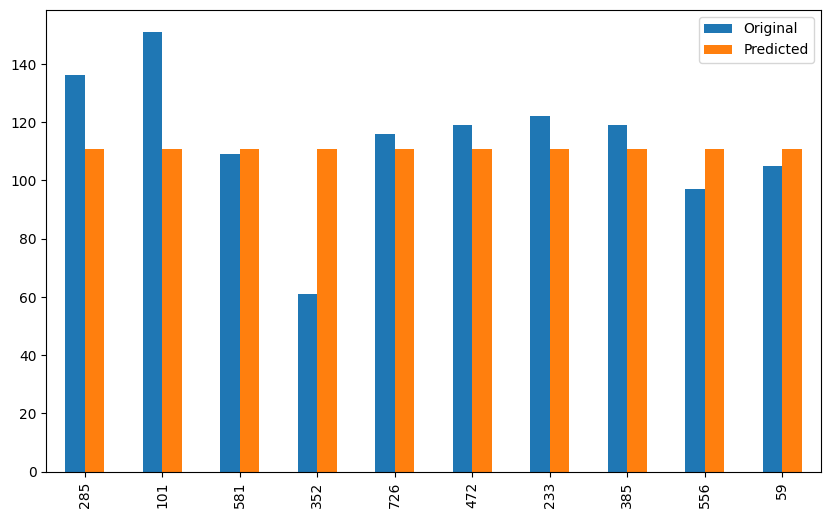

In [13]:
y.head(10).plot(kind="bar", figsize=(10, 6))

#### Evaluation indicators:

In [14]:
from sklearn import metrics

In [15]:
print("----------Evaluation Indicators ---------------")
print(f"MAE: {metrics.mean_absolute_error(y_test, y_pred)}")
print(f'MSE: {metrics.mean_squared_error(y_test, y_pred)}')
print(f"RMSE: {metrics.mean_squared_error(y_test, y_pred)}")
print(f"R-Squared: {metrics.r2_score(y_test, y_pred)}")

----------Evaluation Indicators ---------------
MAE: 22.59647641420356
MSE: 852.3138950266475
RMSE: 852.3138950266475
R-Squared: 0.2450483664855082
